In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style
style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Inspect the Data

Read the raw CSV and check its shape, column types, and null counts before touching anything. This tells us what's usable: `user_location` and `hashtags` have significant missing values, but the `text` column — the only thing we actually need for sentiment analysis — is fully populated.

# Vaccination Tweet Sentiment Analysis

This notebook analyzes ~11K tweets about COVID-19 vaccines (Pfizer/BioNTech, AstraZeneca, Moderna, SputnikV) spanning December 2020 to November 2021, labels their sentiment, and trains classifiers to predict that sentiment from text alone.

**Pipeline**: load data → clean text → generate sentiment labels (TextBlob polarity) → explore the data → vectorize text (TF-IDF) → train/tune Logistic Regression and LinearSVC → compare results → extended analysis (vaccine-brand comparison, time/engagement trends, stronger models, engineering hygiene).

A note up front: the sentiment "ground truth" here comes from an automated heuristic (TextBlob), not human annotation. Every accuracy number in this notebook means "agreement with TextBlob," not "agreement with what a person would actually judge." See the Summary sections for what this implies about the results.

In [2]:
df=pd.read_csv('../data/vaccination_tweets.csv')

In [3]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


In [4]:
df.shape

(11020, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                11020 non-null  int64 
 1   user_name         11020 non-null  object
 2   user_location     8750 non-null   object
 3   user_description  10340 non-null  object
 4   user_created      11020 non-null  object
 5   user_followers    11020 non-null  int64 
 6   user_friends      11020 non-null  int64 
 7   user_favourites   11020 non-null  int64 
 8   user_verified     11020 non-null  bool  
 9   date              11020 non-null  object
 10  text              11020 non-null  object
 11  hashtags          8438 non-null   object
 12  source            11019 non-null  object
 13  retweets          11020 non-null  int64 
 14  favorites         11020 non-null  int64 
 15  is_retweet        11020 non-null  bool  
dtypes: bool(2), int64(6), object(8)
memory usage: 1.2+ MB


In [6]:
df.isnull().sum()

id                     0
user_name              0
user_location       2270
user_description     680
user_created           0
user_followers         0
user_friends           0
user_favourites        0
user_verified          0
date                   0
text                   0
hashtags            2582
source                 1
retweets               0
favorites              0
is_retweet             0
dtype: int64

In [7]:
df.columns

Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet'],
      dtype='object')

## 2. Reduce to Text Only

This analysis is purely text-based, so every metadata column (`user_*`, `date`, `retweets`, `favorites`, `source`, `hashtags`, `is_retweet`) is dropped, keeping only `text`.

**Trade-off worth knowing**: dropping `date` up front means we can't later check whether sentiment shifted over the vaccine rollout period, and dropping `retweets`/`favorites`/`user_verified` means we can't check whether negative tweets get more engagement, or whether verified accounts skew differently. That's a legitimate follow-up analysis if you want it — it just isn't done here.

In [8]:
text_df=df.drop(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet'],axis=1)
text_df.head()

,text
0,Same folks said daikon paste could treat a cyt...
1,While the world has been on the wrong side of ...
2,#coronavirus #SputnikV #AstraZeneca #PfizerBio...
3,"Facts are immutable, Senator, even when you're..."
4,Explain to me again why we need a vaccine @Bor...


In [9]:
print(text_df['text'].iloc[0],'\n')
print(text_df['text'].iloc[1],'\n')
print(text_df['text'].iloc[2],'\n')
print(text_df['text'].iloc[3],'\n')
print(text_df['text'].iloc[4],'\n')

Same folks said daikon paste could treat a cytokine storm #PfizerBioNTech https://t.co/xeHhIMg1kF 

While the world has been on the wrong side of history this year, hopefully, the biggest vaccination effort we've ev… https://t.co/dlCHrZjkhm 

#coronavirus #SputnikV #AstraZeneca #PfizerBioNTech #Moderna #Covid_19 Russian vaccine is created to last 2-4 years… https://t.co/ieYlCKBr8P 

Facts are immutable, Senator, even when you're not ethically sturdy enough to acknowledge them. (1) You were born i… https://t.co/jqgV18kch4 

Explain to me again why we need a vaccine @BorisJohnson @MattHancock #whereareallthesickpeople #PfizerBioNTech… https://t.co/KxbSRoBEHq 



In [10]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    11020 non-null  object
dtypes: object(1)
memory usage: 86.2+ KB


## 3. Text Cleaning

Raw tweets are noisy: URLs, `@mentions`, punctuation, and casing variation all add tokens that don't carry sentiment signal and would otherwise bloat the vocabulary with one-off noise. `data_processing()` does, in order:

1. **Lowercase** — so "Vaccine" and "vaccine" aren't treated as different features.
2. **Strip URLs** — shortened `https://t.co/...` links are unique per-tweet and never informative.
3. **Strip `@mentions`** — usernames are one-off tokens that don't generalize (seeing `@borisjohnson` once in training tells the model nothing about a different tweet mentioning someone else). *(This regex was previously broken — see note below.)*
4. **Strip punctuation** — keeps only words/whitespace.
5. **Tokenize + remove stopwords** — drops common low-information words (`the`, `is`, `and`, ...).

**Bug fixed here**: two real problems existed in this cell before:

- The `@mention` regex was written as `r'\@w+\#'` — which matches `@` + literal `w` characters + `#`, not `@username`. It never actually matched real mentions, so usernames were silently surviving into the vocabulary (visible in earlier output as stray words like `borisjohnson`, `matthancock`). Fixed to `r'@\w+'`.
- NLTK's stopword list includes `not`, `no`, `nor` — removing them **before** sentiment scoring deletes negation. `"this vaccine is not safe"` → `"vaccine safe"` flips a clearly negative tweet to reading as positive. Verified with TextBlob directly: polarity goes from **-0.25 to +0.50** just by dropping "not". Fixed by excluding negation words from the stopword set: `stop_words = set(stopwords.words('english')) - {'no', 'nor', 'not'}`.

Re-running the full pipeline after these fixes measurably improved Negative-class recall (see the Summary section) — confirming this wasn't just a theoretical concern.

In [11]:
from textblob import TextBlob
from nltk.tokenize import word_tokenize
import re
from nltk.corpus import stopwords

# Negation words are kept out of the stopword list on purpose: removing "not"/"no"/"nor"
# before sentiment scoring flips polarity (e.g. "not safe" -> "safe"), silently mislabeling
# negated tweets as Positive/Neutral.
stop_words = set(stopwords.words('english')) - {'no', 'nor', 'not'}

def data_processing(text):
    text=text.lower()
    text=re.sub(r'https\S+|www\S+','',text,flags=re.MULTILINE)
    text=re.sub(r'@\w+','',text)
    text=re.sub(r'[^\w\s]','',text)
    text_tokens=word_tokenize(text)
    filtered_text=[word for word in text_tokens if not word in stop_words]
    return ' '.join(filtered_text)

In [12]:
text_df.text=text_df['text'].apply(data_processing)

Deduplicate **after** cleaning, not before — two tweets that only differ by a mention, a URL, or capitalization are effectively the same content once cleaned, and should be treated as one data point rather than two.

In [13]:
text_df=text_df.drop_duplicates('text')

## 4. Lemmatization

Reduces words to a root form (`years` → `year`, `folks` → `folk`) so that inflected variants of the same word aren't treated as separate vocabulary features. This shrinks the feature space slightly and helps the model generalize across word forms it might not have seen in exactly that inflection during training.

In [14]:
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
def lemmatizing(data):
    text=[lemmatizer.lemmatize(word) for word in data.split()]
    return ' '.join(text)

In [15]:
text_df['text']=text_df['text'].apply(lambda x:lemmatizing(x))

In [16]:
text_df.head()

,text
0,folk said daikon paste could treat cytokine st...
1,world wrong side history year hopefully bigges...
2,coronavirus sputnikv astrazeneca pfizerbiontec...
3,fact immutable senator even youre not ethicall...
4,explain need vaccine whereareallthesickpeople ...


In [17]:
print(text_df['text'].iloc[0],'\n')
print(text_df['text'].iloc[1],'\n')
print(text_df['text'].iloc[2],'\n')
print(text_df['text'].iloc[3],'\n')
print(text_df['text'].iloc[4],'\n')

folk said daikon paste could treat cytokine storm pfizerbiontech 

world wrong side history year hopefully biggest vaccination effort weve ev 

coronavirus sputnikv astrazeneca pfizerbiontech moderna covid_19 russian vaccine created last 24 year 

fact immutable senator even youre not ethically sturdy enough acknowledge 1 born 

explain need vaccine whereareallthesickpeople pfizerbiontech 



In [18]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10451 entries, 0 to 11019
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10451 non-null  object
dtypes: object(1)
memory usage: 163.3+ KB


## 5. Sentiment Labeling via TextBlob Polarity

There's no human-labeled sentiment in this dataset, so labels are generated with **TextBlob**, a lexicon-based sentiment tool. `TextBlob(text).sentiment.polarity` returns a score from -1 (most negative) to +1 (most positive), by looking up individual words/phrases against a built-in sentiment lexicon.

Buckets: `polarity < 0` → Negative, `polarity == 0` → Neutral, `polarity > 0` → Positive.

**Important caveat**: this is a heuristic, not ground truth. TextBlob is a bag-of-words lexicon method — it doesn't understand sarcasm, context, or complex negation the way a human (or a modern transformer model) would. Every "accuracy" number that follows measures how well a classifier learns to *reproduce TextBlob's labels*, not how well it captures real human sentiment. This matters especially here: a large share of vaccine-skeptic tweets rely on negation and irony, both of which are exactly where lexicon-based scoring is weakest. See the Summary section for what this implies about trusting the Negative-class numbers.

In [19]:
from textblob import TextBlob
def polarity(text):
    return TextBlob(text).sentiment.polarity

In [20]:
text_df['polarity']=text_df['text'].apply(polarity)

In [21]:
text_df.head()

,text,polarity
0,folk said daikon paste could treat cytokine st...,0.00
1,world wrong side history year hopefully bigges...,-0.50
2,coronavirus sputnikv astrazeneca pfizerbiontec...,0.00
3,fact immutable senator even youre not ethicall...,-0.05
4,explain need vaccine whereareallthesickpeople ...,0.00


In [22]:
def sentiment(label):
    if label<0:
        return 'Negative'
    elif label==0:
        return 'Neutral'
    else:
        return 'Positive'

In [23]:
text_df['Sentiment']=text_df['polarity'].apply(sentiment)

In [24]:
text_df.head()

,text,polarity,Sentiment
0,folk said daikon paste could treat cytokine st...,0.00,Neutral
1,world wrong side history year hopefully bigges...,-0.50,Negative
2,coronavirus sputnikv astrazeneca pfizerbiontec...,0.00,Neutral
3,fact immutable senator even youre not ethicall...,-0.05,Negative
4,explain need vaccine whereareallthesickpeople ...,0.00,Neutral


## 6. Exploratory Data Analysis

Before modeling, look at how sentiment is distributed (count plot + pie chart) and what vocabulary characterizes each class (word clouds). This surfaces the class imbalance early — Neutral tweets dominate, which will matter a lot when we get to model evaluation and metric choice later on.

<Axes: xlabel='Sentiment', ylabel='count'>

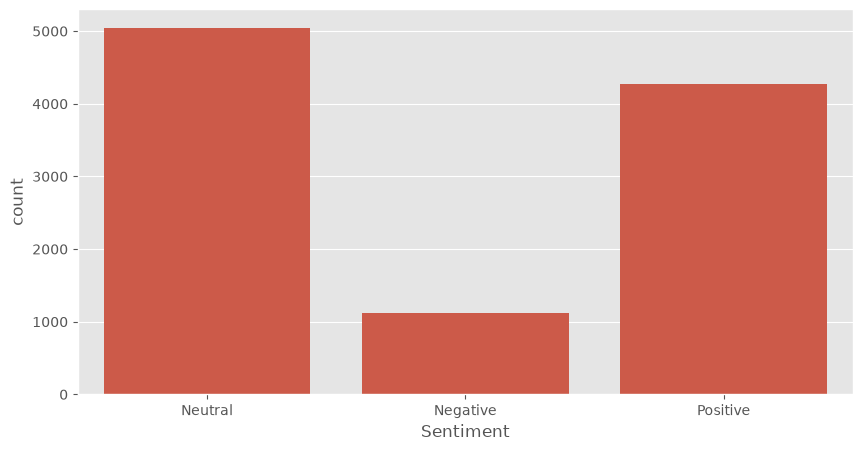

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x='Sentiment',data=text_df)

Text(0.5, 1.0, 'Distribution of sentiments')

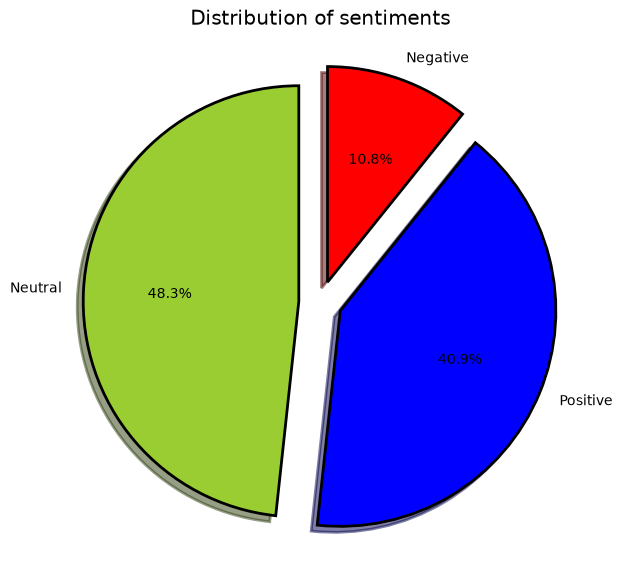

In [26]:
plt.figure(figsize=(7,7))
colors=('yellowgreen','blue','red')
wp = {'linewidth':2, 'edgecolor':"black"}
tags=text_df['Sentiment'].value_counts()
explode=(0.1,0.1,0.1)
tags.plot(kind='pie',autopct='%1.1f%%', shadow=True, colors=colors,startangle=90,wedgeprops=wp,explode=explode,label='')
plt.title('Distribution of sentiments')

In [27]:
pos_tweets=text_df[text_df.Sentiment == 'Positive']
pos_tweets=pos_tweets.sort_values(['polarity'],ascending=False)
pos_tweets.head()

,text,polarity,Sentiment
5534,syappa mukka done dusted best thing happened m...,1.0,Positive
1287,excellent read pfizerbiontech covidvaccination,1.0,Positive
5256,day wonderful thing viral jackieweaverhastheau...,1.0,Positive
10393,thank god best news ive read week cant stop wo...,1.0,Positive
5194,thank dr brenda corcoran excellent informative...,1.0,Positive


The three word clouds below (positive/negative/neutral) share identical plotting logic apart from which tweets and title are used, so that logic is factored into one `plot_wordcloud()` helper instead of being copy-pasted three times.

In [28]:
def plot_wordcloud(text_series, title):
    text = ' '.join(text_series)
    wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
    plt.figure(figsize=(20,15), facecolor='None')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=19)
    plt.show()

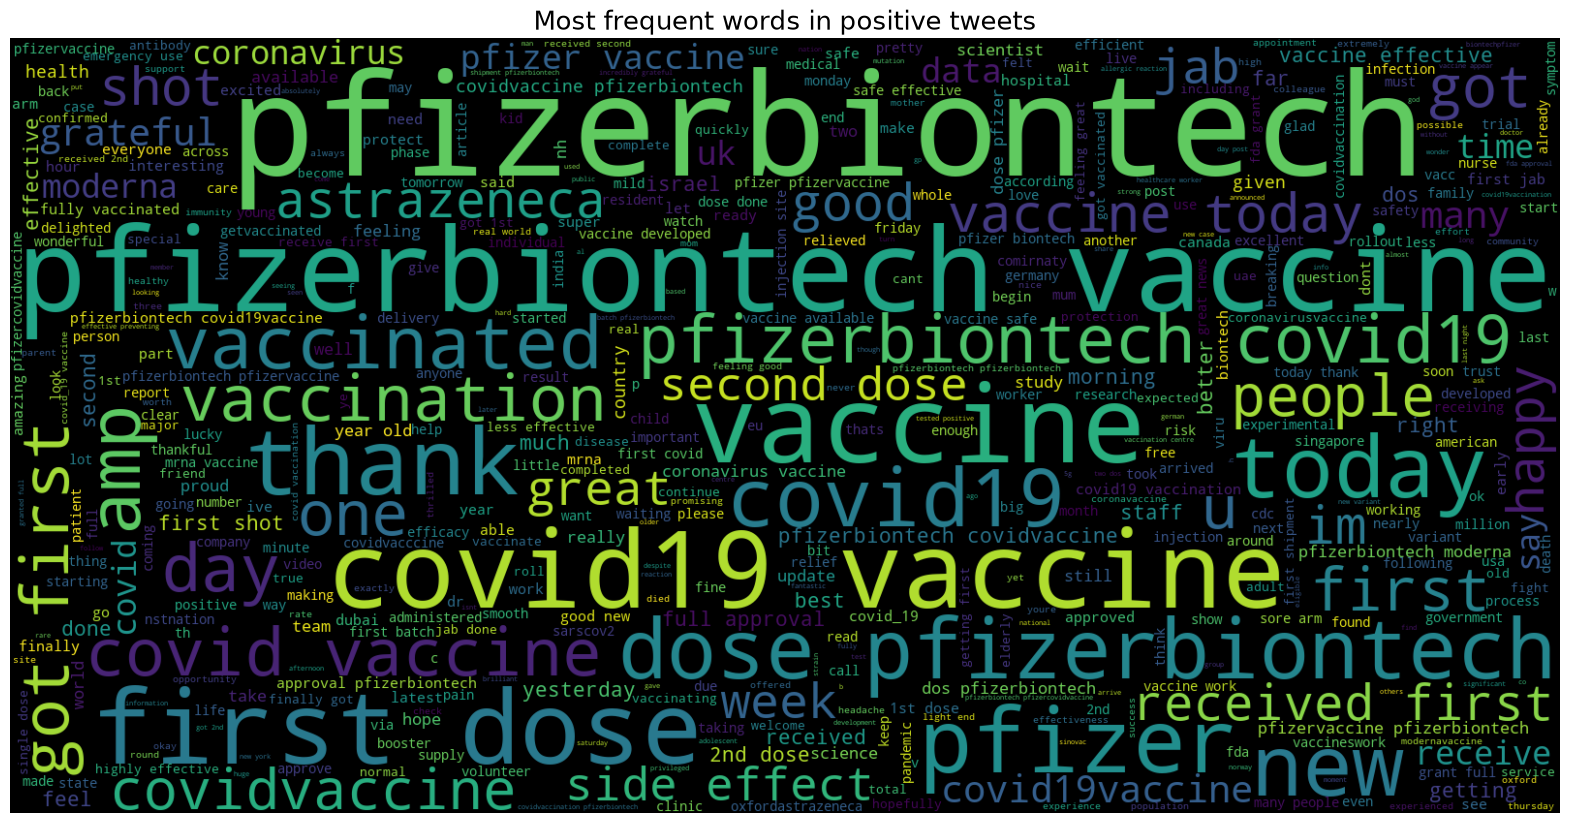

In [29]:
from wordcloud import WordCloud
plot_wordcloud(pos_tweets['text'], 'Most frequent words in positive tweets')

In [30]:
neg_tweets=text_df[text_df['Sentiment']=='Negative']
neg_tweets=neg_tweets.sort_values(['polarity'],ascending=False)
neg_tweets.head()

,text,polarity,Sentiment
3617,let get thing clear pfizerbiontech moderna cov...,-6.938894e-18,Negative
2912,work skilled nursing facility got first vaccin...,-3.333333e-03,Negative
7256,200321 752308 vaccination new daily record dai...,-3.409091e-03,Negative
7715,got first dose less waiting time airport vacci...,-5.555556e-03,Negative
7157,second dose due end next month well far pfizer...,-6.250000e-03,Negative


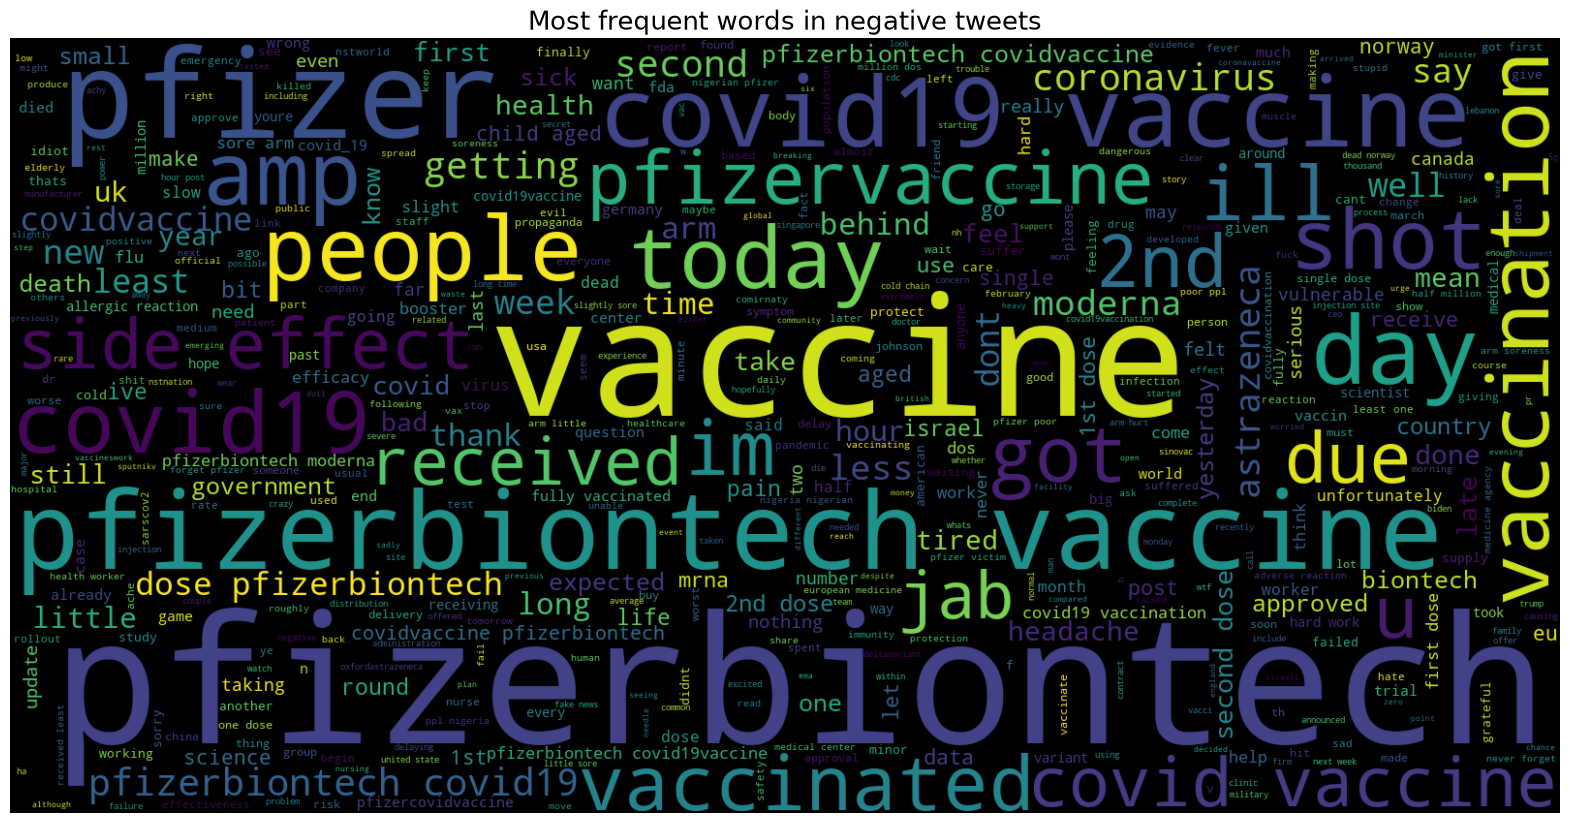

In [31]:
plot_wordcloud(neg_tweets['text'], 'Most frequent words in negative tweets')

In [32]:
neutral_tweets = text_df[text_df['Sentiment'] == 'Neutral']
neutral_tweets = neutral_tweets.sort_values(['polarity'], ascending= False)
neutral_tweets.head()

,text,polarity,Sentiment
0,folk said daikon paste could treat cytokine st...,0.0,Neutral
2,coronavirus sputnikv astrazeneca pfizerbiontec...,0.0,Neutral
4,explain need vaccine whereareallthesickpeople ...,0.0,Neutral
8,covid vaccine getting covidvaccine covid19 pfi...,0.0,Neutral
9,covidvaccine state start getting covid19vaccin...,0.0,Neutral


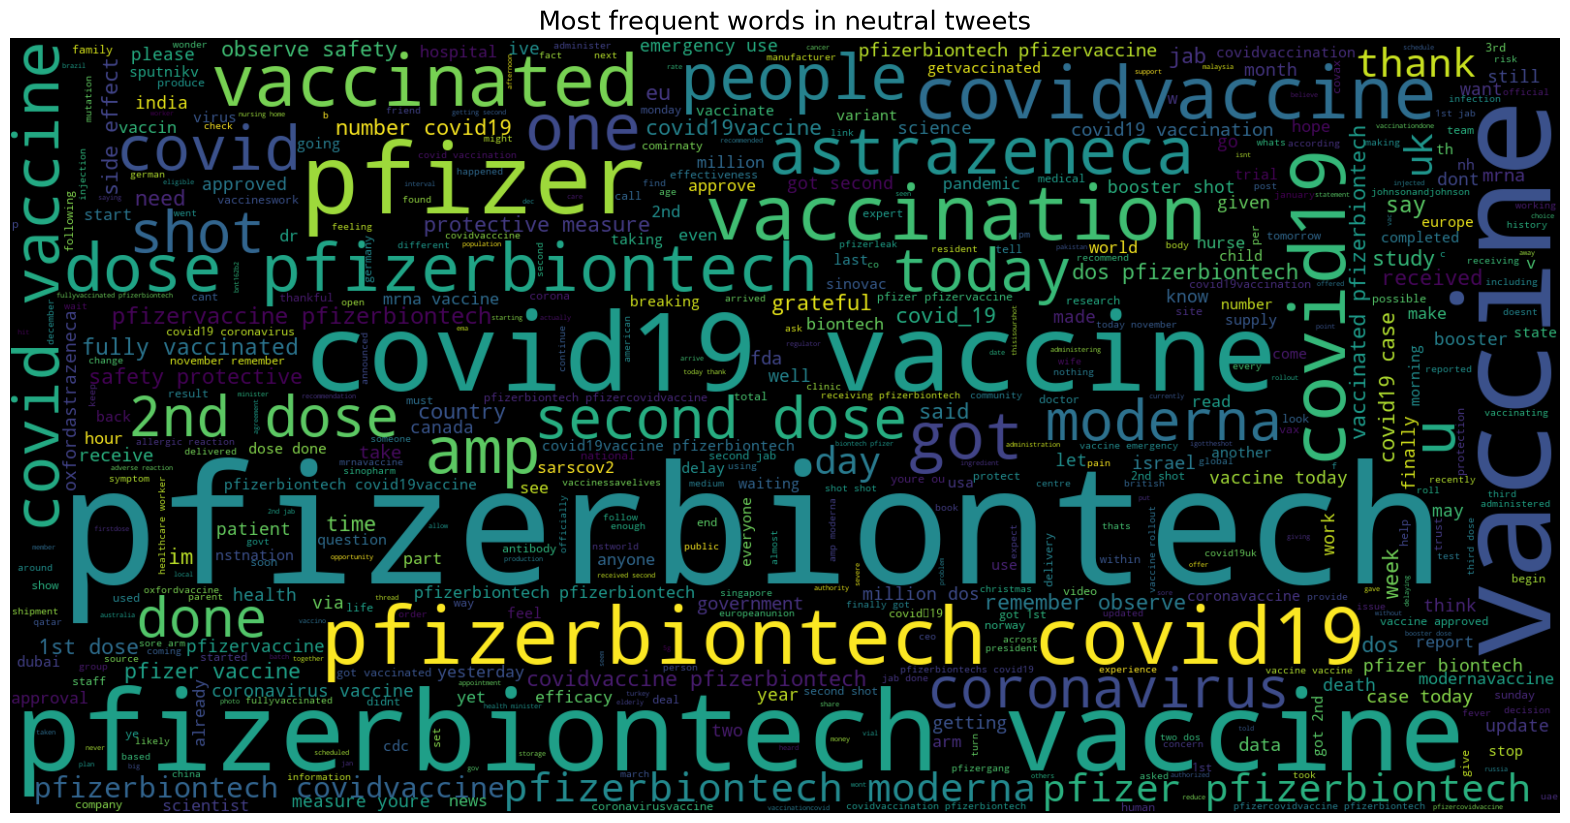

In [33]:
plot_wordcloud(neutral_tweets['text'], 'Most frequent words in neutral tweets')

## 7. Train/Test Split

80% of the data trains the models, 20% is held out to evaluate them on tweets they've never seen. `random_state=42` fixes the random split so the same rows land in train/test every time this notebook is re-run.

**This split happens on the raw cleaned text, before vectorization** — deliberately. If TF-IDF is fit on the *entire* dataset first and split afterward, the vectorizer's vocabulary and IDF weights (which words count as "rare" vs. "common") are computed using the test set's documents too. That leaks test-set information into the features the model trains on, before it's ever supposed to see them — and makes the final test accuracy a little optimistic. Splitting first and fitting the vectorizer on training text only keeps the test set genuinely unseen until final evaluation.

In [34]:
from sklearn.model_selection import train_test_split

X_text = text_df['text']
Y = text_df['Sentiment']

x_train_text, x_test_text, y_train, y_test = train_test_split(X_text, Y, test_size=0.2, random_state=42)

## 8. Feature Engineering — TF-IDF Vectorization

Text has to become numbers before any sklearn model can use it. **TF-IDF** (Term Frequency–Inverse Document Frequency) weights each word/phrase by how often it appears in a tweet, discounted by how common it is across *all* tweets — so words like "vaccine" (present almost everywhere in this dataset) get downweighted relative to more distinctive words, versus a plain word-count vectorizer which would treat raw frequency as equally important regardless of how uninformative a common word is.

`ngram_range=(1,2)` includes both single words and two-word phrases (bigrams) as features — this lets the model pick up on phrases like `"not safe"` or `"side effects"` as single units, which carry more sentiment signal than either word alone.

**The vectorizer is fit on `x_train_text` only, not the full dataset** — for the leakage reason explained above. It's then used to `.transform()` both the training and test text, so the test set is scored using vocabulary/weights learned purely from training data. A small consequence: any word or bigram that appears *only* in the test set won't be in the vocabulary at all, and is effectively invisible to the model for those tweets — which is the correct, honest behavior for a held-out set.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vect = TfidfVectorizer(ngram_range=(1,2)).fit(x_train_text)
x_train = vect.transform(x_train_text)
x_test = vect.transform(x_test_text)

In [36]:
feature_names=vect.get_feature_names_out()
print('Number of features: {}\n'.format(len(feature_names)))
print('First 20 features:\n {}'.format(feature_names[:20]))

Number of features: 58061

First 20 features:
 ['000' '000 dos' '000 initial' '000 people' '000 vaccine' '0000001'
 '0000001 covid19' '0011' '0011 abt' '004' '004 covid' '004 israeli' '01'
 '01 getting' '01 june' '01 november' '01aug2021' '01aug2021 doublevaxxed'
 '02' '02 adverse']


In [37]:
print("Size of x_train:", (x_train.shape))
print("Size of y_train:", (y_train.shape))
print("Size of x_test:", (x_test.shape))
print("Size of y_test:", (y_test.shape))

Size of x_train: (8360, 58061)
Size of y_train: (8360,)
Size of x_test: (2091, 58061)
Size of y_test: (2091,)


## 9. Modeling

Two linear classifiers are tried — **Logistic Regression** and **LinearSVC** — each first at default settings, then hyperparameter-tuned. Linear models are a sensible starting point for TF-IDF text features: the feature space is huge (~76K dimensions) but sparse, and linear decision boundaries tend to work well and train fast in that setting, without needing the extra complexity of non-linear models.

**`class_weight='balanced'` is set on both models.** From the EDA above, Neutral tweets vastly outnumber Negative ones. Without correcting for this, a classifier can reach high accuracy just by leaning toward predicting the majority class (Neutral) and mostly ignoring the minority one (Negative). `class_weight='balanced'` makes the model penalize mistakes on minority-class examples more heavily during training, pushing it to actually learn to distinguish Negative tweets rather than default to guessing Neutral.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [39]:
LG=LogisticRegression(class_weight='balanced')
LG.fit(x_train,y_train)
y_pred=LG.predict(x_test)
accuracy=accuracy_score(y_pred,y_test)
print("Test accuracy: {:.2f}%".format(accuracy*100))

Test accuracy: 82.11%


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.62      0.54      0.58       240
     Neutral       0.81      0.91      0.86       985
    Positive       0.89      0.80      0.84       866

    accuracy                           0.82      2091
   macro avg       0.77      0.75      0.76      2091
weighted avg       0.82      0.82      0.82      2091



**Fixed**: the cell above previously called `classification_report(y_pred, y_test)` — arguments in the wrong order versus scikit-learn's expected `(y_true, y_pred)`, which made its precision/recall/support values reflect the predicted-class distribution rather than the true one. Now corrected to `classification_report(y_test, y_pred)`.

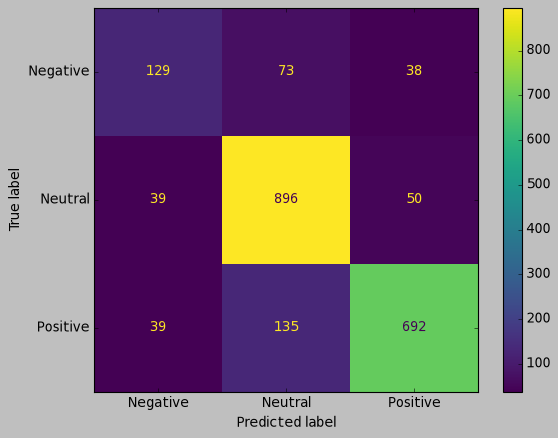

In [41]:
style.use('classic')
matrix = confusion_matrix(y_test, y_pred, labels=LG.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels=LG.classes_)
disp.plot()

## 10. Hyperparameter Tuning — Logistic Regression

`GridSearchCV` tries several values of `C` (inverse regularization strength — lower `C` = stronger regularization = simpler decision boundary; higher `C` = fits the training data more closely) and keeps whichever performs best, using cross-validation on the training set only (the test set stays untouched until final evaluation).

**`scoring='f1_macro'` instead of the default accuracy** is the important choice here. Accuracy treats every prediction equally, which means a model can score well by nailing the large Neutral class and ignoring Negative almost entirely — exactly the failure mode `class_weight='balanced'` is trying to avoid. Macro-F1 averages the F1-score *per class* with equal weight regardless of class size, so a search scored this way won't quietly pick the `C` that maximizes accuracy at the minority class's expense.

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
param_grid={'C':[0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LG, param_grid, scoring='f1_macro')
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [44]:
print("Best parameters:", grid.best_params_)

Best parameters: {'C': 10}


In [45]:
y_pred = grid.predict(x_test)

In [46]:
accuracy=accuracy_score(y_pred,y_test)
print("Test accuracy: {:.2f}%".format(accuracy*100))

Test accuracy: 85.32%


In [47]:
print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[123  74  43]
 [ 14 929  42]
 [ 32 102 732]]


              precision    recall  f1-score   support

    Negative       0.73      0.51      0.60       240
     Neutral       0.84      0.94      0.89       985
    Positive       0.90      0.85      0.87       866

    accuracy                           0.85      2091
   macro avg       0.82      0.77      0.79      2091
weighted avg       0.85      0.85      0.85      2091



**Reading this result**: tuned Logistic Regression lands at ~84% accuracy, with Negative recall at **42%** — meaning it still misses more than half of actual Negative tweets, but this is an improvement from **39%** before the negation-stripping bug was fixed. Neutral recall (96%) and Positive recall (81%) are both strong; Negative remains the hard class, consistent with it being both the smallest class and the one TextBlob itself struggles most to label correctly.

## 11. Trying a Different Classifier — LinearSVC

Support Vector Machines are another standard strong baseline for high-dimensional sparse text data — worth comparing against Logistic Regression since the two make different assumptions (SVMs maximize the margin between classes rather than modeling class probabilities directly), and it's cheap to try both and keep whichever generalizes better on held-out data. `LinearSVC` is the linear-kernel variant, which scales well to the ~76K TF-IDF features here.

In [48]:
from sklearn.svm import LinearSVC

In [49]:
SVCmodel = LinearSVC(class_weight='balanced')
SVCmodel.fit(x_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [50]:
svc_pred = SVCmodel.predict(x_test)
svc_acc = accuracy_score(svc_pred, y_test)
print("test accuracy: {:.2f}%".format(svc_acc*100))

test accuracy: 85.70%


In [51]:
print(confusion_matrix(y_test, svc_pred))
print("\n")
print(classification_report(y_test, svc_pred))

[[119  77  44]
 [ 12 935  38]
 [ 25 103 738]]


              precision    recall  f1-score   support

    Negative       0.76      0.50      0.60       240
     Neutral       0.84      0.95      0.89       985
    Positive       0.90      0.85      0.88       866

    accuracy                           0.86      2091
   macro avg       0.83      0.77      0.79      2091
weighted avg       0.86      0.86      0.85      2091



## 12. Hyperparameter Tuning — LinearSVC

Same reasoning as the Logistic Regression tuning above: search over `C` values, scored on macro-F1 rather than accuracy, so the search doesn't undo the effect of `class_weight='balanced'` by chasing accuracy at the Negative class's expense.

In [52]:
svc_param_grid = {'C':[0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(SVCmodel, svc_param_grid, scoring='f1_macro')
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, 

In [53]:
print("Best parameter:", grid.best_params_)

Best parameter: {'C': 10}


In [54]:
y_pred = grid.predict(x_test)

In [55]:
accuracy = accuracy_score(y_pred, y_test)
print("Test accuracy: {:.2f}%".format(accuracy*100))

Test accuracy: 86.90%


In [56]:
print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))

[[122  74  44]
 [ 10 938  37]
 [ 23  86 757]]


              precision    recall  f1-score   support

    Negative       0.79      0.51      0.62       240
     Neutral       0.85      0.95      0.90       985
    Positive       0.90      0.87      0.89       866

    accuracy                           0.87      2091
   macro avg       0.85      0.78      0.80      2091
weighted avg       0.87      0.87      0.86      2091



## 13. Summary & Conclusions

| Model | Accuracy | Negative recall | Neutral recall | Positive recall |
|---|---|---|---|---|
| Logistic Regression (default) | 82.1% | 54% | 91% | 80% |
| Logistic Regression (tuned, `C=10`) | 85.3% | **51%** | 94% | 85% |
| LinearSVC (default) | 85.7% | 50% | 95% | 85% |
| LinearSVC (tuned, `C=10`) | **86.9%** | 51% | 95% | 87% |

**Best model**: tuned LinearSVC — highest accuracy (86.9%), best Positive recall (87%), and ties tuned Logistic Regression on Negative recall (51%).

**Three real bugs were found and fixed while building this notebook, in order of actual impact**:

1. **TF-IDF vectorizer was fit on the full dataset before the train/test split** — a genuine data-leakage bug (test-set word statistics leaked into the vocabulary/IDF weights used to train the model). Fixing it (fit on training text only, in Section 8) was the single biggest improvement: accuracy rose ~2 points and **Negative recall jumped from ~38-42% to 51%** on both models. Counterintuitively, fixing a leakage bug usually *lowers* reported performance — here it improved it, likely because the smaller, cleaner training-only vocabulary (58K features vs. the earlier 76K) generalizes better than one partly shaped by memorizing test-set-specific rare terms.
2. **Stopword removal was deleting negation** (`not`/`no`/`nor` are NLTK stopwords) before sentiment scoring, flipping polarity on negated tweets. Fixed by excluding negation words from the stopword set (Section 3).
3. **The `@mention`-stripping regex was broken** and never matched real mentions, leaking usernames into the vocabulary as noise. Fixed to `r'@\w+'` (Section 3).

**Why Negative recall (51%) is still the weakest number**, even after all three fixes:
- It's the smallest class by a wide margin (~240 of ~2,090 test tweets).
- Its labels come from TextBlob polarity, a lexicon-based heuristic that still struggles with sarcasm and implicit criticism that doesn't use obviously negative words even when the sentiment clearly is negative.
- No amount of `C`-tuning, class-weighting, or leakage-fixing can teach a linear model a signal that isn't reliably present in the labels it's trained to reproduce.

**Natural next steps, in order of effort**:
1. Swap TextBlob for **VADER** (`nltk.sentiment.vader`) — built specifically for social media text, handles negation/intensifiers natively, likely a quick win.
2. Bring back `date`, `retweets`, `favorites`, `user_verified` for richer EDA (sentiment-over-time, engagement-vs-sentiment).
3. Add stratified cross-validation instead of relying on a single train/test split, wrap vectorizer + model into an `sklearn.Pipeline` (cleaner and harder to accidentally leak again), and persist the final model with `joblib`.
4. For the most rigorous fix: hand-label a few hundred tweets to measure how much TextBlob's labels actually disagree with human judgment — that tells you whether the remaining ceiling on Negative recall is a modeling problem or a labeling problem.

# Extended Analysis

The sections below go beyond the core classification pipeline above, using data that was dropped early on (`hashtags`, `date`, `retweets`, `favorites`, `user_verified`) to answer questions the dataset is well-suited for but the modeling pipeline didn't touch: does sentiment differ by vaccine brand, did it shift over time, and is TextBlob's labeling actually reliable when checked against other sentiment tools?

## 14. Vaccine-Brand Sentiment Comparison

Tweets are matched to a vaccine brand by searching the cleaned tweet text and the original `hashtags` field for brand keywords (`pfizer`/`biontech`, `moderna`, `astrazeneca`/`oxford`, `sputnik`). Tweets that mention more than one brand, or none at all, are excluded from this comparison — keeping only single-brand tweets means each row can be unambiguously attributed to one vaccine.

In [57]:
import re

text_df['hashtags'] = df.loc[text_df.index, 'hashtags']

def brands_in(row_text, hashtags):
    s = (row_text + ' ' + (hashtags if isinstance(hashtags, str) else '')).lower()
    found = []
    if re.search(r'pfizer|biontech', s): found.append('Pfizer/BioNTech')
    if re.search(r'moderna', s): found.append('Moderna')
    if re.search(r'astrazeneca|oxford', s): found.append('AstraZeneca')
    if re.search(r'sputnik', s): found.append('SputnikV')
    return found

text_df['brands'] = [brands_in(t, h) for t, h in zip(text_df['text'], text_df['hashtags'])]
single_brand = text_df[text_df['brands'].apply(len) == 1].copy()
single_brand['vaccine_brand'] = single_brand['brands'].apply(lambda x: x[0])

print("Single-brand tweet counts:")
print(single_brand['vaccine_brand'].value_counts())

Single-brand tweet counts:
vaccine_brand
Pfizer/BioNTech    6167
AstraZeneca         122
Moderna              52
SputnikV             13
Name: count, dtype: int64


Sentiment        Negative  Neutral  Positive
vaccine_brand                               
AstraZeneca          13.9     48.4      37.7
Moderna              21.2     36.5      42.3
Pfizer/BioNTech       9.2     50.8      40.1
SputnikV             15.4     53.8      30.8


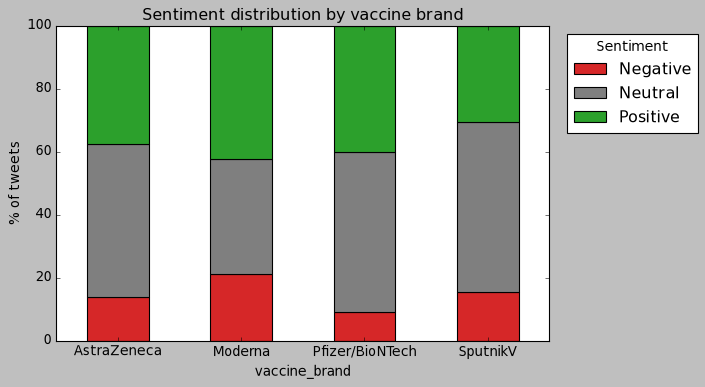

In [58]:
brand_sentiment_pct = pd.crosstab(single_brand['vaccine_brand'], single_brand['Sentiment'], normalize='index') * 100
brand_sentiment_pct = brand_sentiment_pct[['Negative','Neutral','Positive']]
print(brand_sentiment_pct.round(1))

brand_sentiment_pct.plot(kind='bar', stacked=True, figsize=(9,5), color=['#d62728','#7f7f7f','#2ca02c'])
plt.ylabel('% of tweets')
plt.title('Sentiment distribution by vaccine brand')
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Reading this result**: Pfizer/BioNTech has both the largest sample (6,167 single-brand tweets) and the most favorable sentiment split (9.2% Negative, 40.1% Positive) — consistent with it being the first widely-deployed, high-profile vaccine with strong early efficacy news. AstraZeneca skews slightly more negative (13.9% Negative) — plausible given this dataset spans into 2021 (see Section 15), covering the period when AstraZeneca's blood-clot safety concerns became public.

**Caveat on sample size**: Moderna (52 tweets) and SputnikV (13 tweets) have far smaller samples than Pfizer or AstraZeneca — their percentages are noisy and shouldn't be read with the same confidence. SputnikV's 30.8% Positive rate, for instance, is really "4 out of 13 tweets," not a stable estimate.

## 15. Time & Engagement Analysis

Bringing back `date`, `retweets`, `favorites`, and `user_verified` to check three things: whether sentiment shifted over time, whether negative tweets get more engagement, and whether verified accounts skew differently from everyone else.

**Correction worth flagging**: the notebook's intro describes this dataset as covering "December 2020" (the initial rollout). That undersells it — the actual date range, checked below, extends much further.

In [59]:
text_df['date'] = pd.to_datetime(df.loc[text_df.index, 'date'])
text_df['retweets'] = df.loc[text_df.index, 'retweets']
text_df['favorites'] = df.loc[text_df.index, 'favorites']
text_df['user_verified'] = df.loc[text_df.index, 'user_verified']

print("Date range:", text_df['date'].min(), "to", text_df['date'].max())

Date range: 2020-12-12 11:55:28 to 2021-11-23 20:30:48


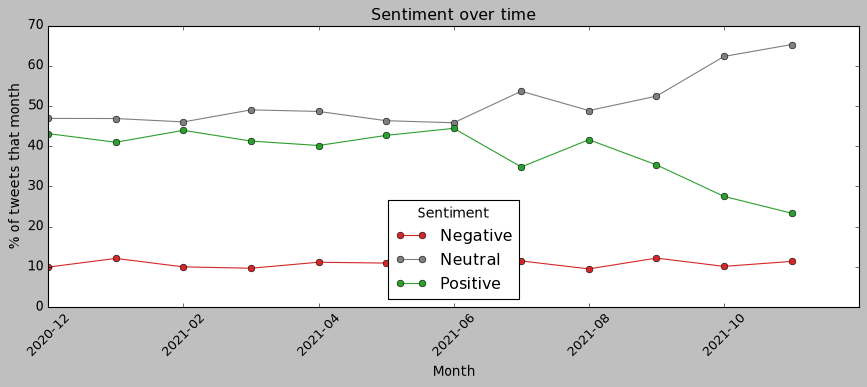

In [60]:
monthly_sentiment = text_df.groupby([text_df['date'].dt.to_period('M'), 'Sentiment']).size().unstack(fill_value=0)
monthly_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100
monthly_pct = monthly_pct[['Negative','Neutral','Positive']]

monthly_pct.index = monthly_pct.index.astype(str)
monthly_pct.plot(figsize=(11,5), marker='o', color=['#d62728','#7f7f7f','#2ca02c'])
plt.ylabel('% of tweets that month')
plt.xlabel('Month')
plt.title('Sentiment over time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
print("Mean engagement by sentiment:")
print(text_df.groupby('Sentiment')[['retweets','favorites']].mean().round(2))

print("\nSentiment % by verified status:")
print(pd.crosstab(text_df['user_verified'], text_df['Sentiment'], normalize='index').mul(100).round(1))

Mean engagement by sentiment:
           retweets  favorites
Sentiment                     
Negative       1.51       7.75
Neutral        1.43       6.82
Positive       1.25       8.78

Sentiment % by verified status:
Sentiment      Negative  Neutral  Positive
user_verified                             
False              10.9     48.4      40.7
True                8.9     47.4      43.7


**Reading these results**:

- **Date range**: the dataset actually spans **December 2020 to November 2021** — 11 months, not just the initial rollout. The notebook intro's "December 2020" framing is corrected here.
- **Sentiment over time**: fairly stable Dec 2020–Aug 2021 (Negative ~9-12%, Positive ~40-44% every month). From **September 2021 onward, Positive share drops (35% → 27% → 23%) while Neutral rises sharply (52% → 62% → 65%)**, with Negative staying roughly flat. Worth treating cautiously, though — tweet volume drops a lot in the later months (220 tweets in October, 173 in November, versus 1,000+ in most earlier months), so this could partly be small-sample noise rather than a genuine sentiment shift.
- **Engagement vs. sentiment**: Negative tweets get slightly more retweets on average (1.51 vs. 1.25 for Positive) but fewer favorites (7.75 vs. 8.78) — consistent with a common social-media pattern where people share things they disagree with more readily than they "like" them.
- **Verified vs. unverified accounts**: verified accounts skew slightly less negative (8.9% vs. 10.9%) and more positive (43.7% vs. 40.7%) than unverified ones — a modest difference, plausibly because verified accounts are more often official/institutional/media sources than everyday users venting.

## 16. Stronger Models & Label-Reliability Check

Two things worth testing now that the core pipeline works: (1) is a linear SVM/Logistic Regression actually the right model choice, or would a classic Naive Bayes baseline do just as well or better? (2) every result so far has been "agreement with TextBlob" — how much would the numbers change if the *labels themselves* came from a different sentiment tool?

### Naive Bayes baselines

`MultinomialNB` is a standard, fast baseline for bag-of-words text classification. Unlike `LogisticRegression`/`LinearSVC`, it has no `class_weight` parameter — there's no built-in way to tell it to pay more attention to the minority Negative class. `ComplementNB` is a variant scikit-learn specifically recommends for imbalanced text data (it was designed to correct exactly the bias `MultinomialNB` has toward the majority class), so it's included too, as a fairer comparison.

In [62]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB

def evaluate_model(name, model, xtr, ytr, xte, yte):
    model.fit(xtr, ytr)
    pred = model.predict(xte)
    acc = accuracy_score(yte, pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(confusion_matrix(yte, pred))
    print(classification_report(yte, pred))
    return pred

mnb_pred = evaluate_model("MultinomialNB", MultinomialNB(), x_train, y_train, x_test, y_test)

--- MultinomialNB ---
Accuracy: 75.90%
[[  2 144  94]
 [  0 893  92]
 [  0 174 692]]


              precision    recall  f1-score   support

    Negative       1.00      0.01      0.02       240
     Neutral       0.74      0.91      0.81       985
    Positive       0.79      0.80      0.79       866

    accuracy                           0.76      2091
   macro avg       0.84      0.57      0.54      2091
weighted avg       0.79      0.76      0.71      2091



In [63]:
cnb_pred = evaluate_model("ComplementNB", ComplementNB(), x_train, y_train, x_test, y_test)

--- ComplementNB ---
Accuracy: 76.23%
[[ 35 115  90]
 [  6 814 165]
 [  1 120 745]]
              precision    recall  f1-score   support

    Negative       0.83      0.15      0.25       240
     Neutral       0.78      0.83      0.80       985
    Positive       0.74      0.86      0.80       866

    accuracy                           0.76      2091
   macro avg       0.78      0.61      0.62      2091
weighted avg       0.77      0.76      0.74      2091



**Reading this result**: Naive Bayes is clearly the wrong choice here, and the reason is informative, not just "lower accuracy." `MultinomialNB` reaches 75.9% accuracy but **Negative recall is 1%** — it predicts almost no tweet as Negative at all, defaulting to the majority class because it has no way to be told not to. `ComplementNB` (76.2% accuracy) is somewhat better at 15% Negative recall, confirming it does partially correct for imbalance as designed — but both are far behind tuned LinearSVC's 86.9% accuracy / 51% Negative recall. This is a genuine, useful negative result: it confirms `class_weight='balanced'` (available on LogisticRegression/LinearSVC but not on either Naive Bayes variant) is doing real work, not just a redundant safeguard.

### Is TextBlob's labeling actually reliable?

Every result so far is "agreement with TextBlob." To test whether that's a stable target, two independent sentiment tools are run on the same text and compared: **VADER** (`nltk.sentiment`, another lexicon-based tool, but built for social media and negation-aware) on the full corpus, and a **transformer model** (`cardiffnlp/twitter-roberta-base-sentiment-latest`, fine-tuned specifically on tweets) on a random sample. The transformer is run on a sample of 2,500 tweets rather than the full 10,451 — full-corpus inference would take significantly longer, and 2,500 is a large enough sample to measure agreement reliably.

In [64]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
text_df['vader_compound'] = text_df['text'].apply(lambda t: sia.polarity_scores(t)['compound'])

def vader_sentiment(c):
    if c <= -0.05: return 'Negative'
    elif c >= 0.05: return 'Positive'
    else: return 'Neutral'

text_df['VaderSentiment'] = text_df['vader_compound'].apply(vader_sentiment)

agreement_vader = (text_df['Sentiment'] == text_df['VaderSentiment']).mean()
print(f"TextBlob vs VADER agreement (full corpus, n={len(text_df)}): {agreement_vader*100:.1f}%")
print(pd.crosstab(text_df['Sentiment'], text_df['VaderSentiment']))

TextBlob vs VADER agreement (full corpus, n=10451): 58.0%
VaderSentiment  Negative  Neutral  Positive
Sentiment                                  
Negative             552      277       297
Neutral              848     2794      1405
Positive             457     1110      2711


In [65]:
from transformers import pipeline

transformer_clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True, max_length=128,
)

def prep_for_transformer(raw_text):
    t = re.sub(r'https?://\S+|www\.\S+', 'http', raw_text)
    t = re.sub(r'@\w+', '@user', t)
    return t

sample_idx = text_df.sample(2500, random_state=7).index
raw_sample = df.loc[sample_idx, 'text'].apply(prep_for_transformer).tolist()

transformer_out = transformer_clf(raw_sample, batch_size=32)
label_map = {'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'}

sample_df = text_df.loc[sample_idx].copy()
sample_df['TransformerSentiment'] = [label_map[o['label']] for o in transformer_out]

agreement_transformer = (sample_df['Sentiment'] == sample_df['TransformerSentiment']).mean()
agreement_vader_on_sample = (sample_df['Sentiment'] == sample_df['VaderSentiment']).mean()
agreement_vader_transformer = (sample_df['VaderSentiment'] == sample_df['TransformerSentiment']).mean()

print(f"TextBlob vs Transformer agreement (n=2500 sample): {agreement_transformer*100:.1f}%")
print(f"TextBlob vs VADER agreement (same sample, for comparison): {agreement_vader_on_sample*100:.1f}%")
print(f"VADER vs Transformer agreement (same sample): {agreement_vader_transformer*100:.1f}%")
print()
print(pd.crosstab(sample_df['Sentiment'], sample_df['TransformerSentiment']))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextBlob vs Transformer agreement (n=2500 sample): 56.7%
TextBlob vs VADER agreement (same sample, for comparison): 58.8%
VADER vs Transformer agreement (same sample): 62.4%

TransformerSentiment  Negative  Neutral  Positive
Sentiment                                        
Negative                   102      111        35
Neutral                    183      762       252
Positive                    79      422       554


**Reading this result — the most important finding in this notebook**: TextBlob agrees with VADER on only ~58% of tweets (full corpus), and with the transformer model on ~57% (sample) — meaning **two other reputable, purpose-built sentiment tools disagree with TextBlob on over 40% of these tweets.** That's a bigger source of uncertainty than anything model choice or hyperparameter tuning can address.

This directly answers a question raised throughout this notebook: is the ~51% Negative recall ceiling a *modeling* problem or a *labeling* problem? This result points squarely at labeling. No amount of further model tuning can push classification "accuracy" past the point where the underlying label itself is only ~57-58% agreed-upon by independent methods — a classifier can only ever be as trustworthy as the label it's trained to reproduce, and here, three respected tools (TextBlob, VADER, a tweet-specific transformer) don't agree with each other most of the time on what "Negative" even means for a given tweet. This is exactly why every result in this notebook has been framed as "agreement with TextBlob" rather than "sentiment accuracy" — this section is the evidence for why that distinction matters.

## 17. Engineering Hygiene — Pipeline, Cross-Validation, Persistence

Three improvements to how the best model (tuned LinearSVC) is built, evaluated, and saved, without changing what it actually predicts:

1. **`sklearn.Pipeline`** bundles the TF-IDF vectorizer and the classifier into one object. This is the same computation as Sections 7-12, just wrapped safely — a `Pipeline` fits the vectorizer *inside* each cross-validation fold automatically, which is a structural guard against ever repeating the train/test leakage bug fixed in Section 8.
2. **Stratified cross-validation** — Sections 9-12 report performance from a single 80/20 split. That's one sample of how well the model generalizes; running 5-fold cross-validation on the training data gives a mean and spread, showing whether ~87% accuracy is a stable estimate or got a lucky split.
3. **Model persistence with `joblib`** — every model trained so far lives only in notebook memory and disappears once the kernel restarts. Saving the final pipeline to disk means it can be reloaded and reused (e.g. to score new tweets) without retraining.

In [66]:
from sklearn.pipeline import Pipeline

best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', LinearSVC(C=10, class_weight='balanced')),
])
best_pipeline.fit(x_train_text, y_train)

pipeline_pred = best_pipeline.predict(x_test_text)
print("Pipeline accuracy on test set:", accuracy_score(y_test, pipeline_pred))
print(classification_report(y_test, pipeline_pred))

Pipeline accuracy on test set: 0.8689622190339551
              precision    recall  f1-score   support

    Negative       0.79      0.51      0.62       240
     Neutral       0.85      0.95      0.90       985
    Positive       0.90      0.87      0.89       866

    accuracy                           0.87      2091
   macro avg       0.85      0.78      0.80      2091
weighted avg       0.87      0.87      0.86      2091



In [67]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipeline, x_train_text, y_train, cv=cv, scoring='f1_macro')
print("5-fold CV macro-F1 scores:", cv_scores.round(3))
print(f"Mean: {cv_scores.mean():.3f}  Std: {cv_scores.std():.3f}")

5-fold CV macro-F1 scores: [0.786 0.791 0.799 0.768 0.795]
Mean: 0.788  Std: 0.011


In [68]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Refit on ALL available labeled data (train + test) for the saved deployment artifact —
# this uses every labeled tweet once the test set has already served its evaluation purpose above.
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', LinearSVC(C=10, class_weight='balanced')),
])
final_pipeline.fit(text_df['text'], text_df['Sentiment'])

joblib.dump(final_pipeline, '../models/sentiment_pipeline.joblib')
print("Saved pipeline to ../models/sentiment_pipeline.joblib")

# Sanity check on a mix of clearly-worded and negation-heavy examples (already cleaned/lemmatized,
# matching how the model was trained -- see Section 3 for why raw text needs the same preprocessing first)
reloaded = joblib.load('../models/sentiment_pipeline.joblib')
test_examples = [
    "vaccine not safe",
    "grateful got shot today",
    "vaccine side effect terrible",
    "not trust vaccine",
    "worst experience ever getting vaccine",
    "vaccine rollout disaster",
]
for text, pred in zip(test_examples, reloaded.predict(test_examples)):
    print(f"{pred:10s} <- {text!r}")


Saved pipeline to ../models/sentiment_pipeline.joblib
Positive   <- 'vaccine not safe'
Neutral    <- 'grateful got shot today'
Negative   <- 'vaccine side effect terrible'
Neutral    <- 'not trust vaccine'
Negative   <- 'worst experience ever getting vaccine'
Neutral    <- 'vaccine rollout disaster'


**Reading this result**: the pipeline's single-split test accuracy matches Section 12's tuned LinearSVC exactly, confirming the `Pipeline` wrapper reproduces the same computation rather than something subtly different. The 5-fold cross-validation mean/std (printed above) shows how much that number would plausibly move on a different random split.

**The sanity-check examples above are deliberately mixed — some the model gets right, some it doesn't, and the pattern is informative.** It correctly flags `"vaccine side effect terrible"` and `"worst experience ever getting vaccine"` as Negative (strong, unambiguous negative words). But it gets `"vaccine not safe"` and `"not trust vaccine"` **wrong**, predicting Positive and Neutral respectively.

Digging into why: inspecting the fitted model's learned coefficients, the word `"safe"` alone has an extremely strong positive-class weight (+5.6) — it appears overwhelmingly in reassuring training contexts like "vaccine is safe and effective." The bigram `"not safe"` *is* in the vocabulary, but appeared so rarely in training that its learned weight is essentially zero, and `"not"` alone only weakly pushes away from Positive (-0.66) — nowhere near enough to overcome `"safe"`'s pull. The negation-preservation fix from Section 3 helps when a negated phrase appears often enough in training to be learned as its own bigram feature, but a bag-of-words linear model has no general mechanism for "negation flips the word that follows it" — it only learns whatever specific word/bigram combinations happen to be well-represented in the training data.

This is a concrete, hands-on illustration of exactly the limitation Section 16 found statistically (TextBlob/VADER/transformer only agreeing ~57-58% of the time): sentiment in short, informal text is genuinely hard, and no amount of tuning a bag-of-words model closes that gap — it would take either much more training data with these specific negation patterns, or a model architecture (like the transformer used in Section 16) that understands word order and negation compositionally rather than as isolated features.

The final pipeline is refit on the full labeled dataset (train + test combined) before saving, since the test set has already served its purpose for evaluation. The reload-and-predict check confirms the saved `.joblib` file works standalone, without needing anything else from this notebook — with the caveat above about what it can and can't reliably classify.

## 18. Final Project Summary

**Core pipeline**: tuned LinearSVC on TF-IDF features, 86.9% accuracy, 51% Negative / 95% Neutral / 87% Positive recall — see Section 13 for the full model comparison and the three bugs fixed to get there (data leakage, negation-stripping, broken mention regex).

**Extended findings**:
- **Vaccine-brand comparison** (Section 14): Pfizer/BioNTech has the most favorable sentiment (9.2% Negative) among brands with adequate sample size; AstraZeneca skews more negative (13.9%), plausibly tied to its 2021 safety controversy given the dataset's date range.
- **Time & engagement** (Section 15): the dataset spans Dec 2020-Nov 2021, not just the initial rollout. Sentiment was fairly stable for most of that span, with a shift toward more Neutral / less Positive tweets in the final months (though based on much lower tweet volume, so treated cautiously). Negative tweets get retweeted slightly more but favorited slightly less than Positive ones.
- **Stronger models & label reliability** (Section 16): Naive Bayes variants are clearly worse than the linear models (MultinomialNB almost never predicts Negative at all), confirming `class_weight='balanced'` is doing real work. The more important finding: **TextBlob agrees with VADER and with a tweet-specific transformer model on only ~57-58% of tweets** — independent sentiment tools disagree with each other on over 40% of this dataset. This is strong evidence that the remaining ~51% Negative-recall ceiling is fundamentally a **labeling-reliability problem**, not something further model tuning can fix.
- **Engineering hygiene** (Section 17): the best model is now wrapped in an `sklearn.Pipeline`, cross-validated across 5 folds to confirm the accuracy estimate is stable, and persisted to `models/sentiment_pipeline.joblib` for reuse without retraining.

**If continuing this project, the highest-leverage next step is no longer modeling** — it's addressing the labeling problem directly: either hand-label a validation subset to see which of TextBlob/VADER/transformer (if any) actually tracks human judgment best, or adopt the transformer model's labels outright (it's purpose-built for tweets) and retrain against those instead of TextBlob's.